# Here is the repository link used for this project: [github link](https://github.com/WBS-UWG/DataAnalyticsProject01)

## 1. Imports et configuration

In [26]:
from io import StringIO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.max_columns", 50)


## 2. Convert TSV file to CSV


In [27]:
SOURCE_PATH = "datasource/launchlog.tsv"
DATA_PATH = "datasource/launchlog.csv"

with open(SOURCE_PATH, "r", encoding="utf-8") as source_file:
    raw_text = "".join(
        line.lstrip("#")
        for line in source_file
        if not line.startswith("# Updated")
    )

converted = pd.read_csv(
    StringIO(raw_text), sep="\t", dtype="string", low_memory=False, na_values=["-"]
)
converted.columns = converted.columns.str.strip()
converted.to_csv(DATA_PATH, index=False, encoding="utf-8")
print(f"File successfully converted and saved to {DATA_PATH}.")


File successfully converted and saved to datasource/launchlog.csv.


In [28]:
USED_COLUMNS = ["Launch_Tag", "Name", "Launch_Date", "SatState", "LVState", "LV_Type"]

df = pd.read_csv(
    DATA_PATH,
    usecols=USED_COLUMNS,
    dtype="string",
    low_memory=False,
    na_values=["-"],
)

df = df[~df["Launch_Tag"].astype(str).str.startswith("#")].copy()

print(f"{len(df):,} lignes (objets/satellites) chargées")
df.head()


31,461 lignes (objets/satellites) chargées


,Launch_Tag,Launch_Date,Name,SatState,LV_Type,LVState
0,1957 ALP,1957 Oct 4 1928:34,1-y ISZ,SU,Sputnik 8K71PS,SU
1,1957 BET,1957 Nov 3 0230:42,2-y ISZ,SU,Sputnik 8K71PS,SU
2,1957-F01,1957 Dec 6 1644:35,Vanguard,US,Vanguard,US
3,1958 ALP,1958 Feb 1 0347:56,Explorer I,US,Jupiter C,US
4,1958-F01,1958 Feb 5 0733,Vanguard,US,Vanguard,US


## 3. Nettoyage des données
The duplicates mainly come from some satellites that blow up and now are multiple pieces in orbit


In [29]:
number_of_satellites_before_cleaning = len(df)

df["Year"] = df["Launch_Date"].astype(str).str.extract(r"^(\d{4})")
df = df.dropna(subset=["Year"])
df["Year"] = df["Year"].astype(int)

# Filter to remove satellites maybes launch outside the bounds of dataset (1957-2026)
current_year = 2026
df = df[(df["Year"] >= 1957) & (df["Year"] <= current_year)]

duplicates_removed = df[df.duplicated(subset=["Launch_Tag", "Name"], keep="first")]
df = df.drop_duplicates(subset=["Launch_Tag", "Name"])

print(f"Total lines of data {number_of_satellites_before_cleaning:,}")
print(f"Number of satellites removed after cleaning: {number_of_satellites_before_cleaning - len(df)}")
print("Duplicates removed:")
for index, row in duplicates_removed.iterrows():
    print(f"  - {row['Launch_Tag']} ({row['Name']}) ({row['Launch_Date']})")
print(f"Total lines of data after cleaning: {len(df):,}")

COUNTRY_NAMES = {
    "US": "United States", "SU": "URSS", "RU": "Russia", "CN": "China",
    "F": "France", "J": "Japan", "IN": "India", "UK": "United Kingdom",
    "D": "Germany", "I": "Italy", "CA": "Canada", "IL": "Israël",
    "KR": "South Korea", "ESA": "ESA (Europe)", "EUME": "EUMETSAT",
    "LUX": "Luxembourg", "UAE": "Emirats arabes unis", "IR": "Iran",
    "KP": "North Korea", "BR": "Brazil", "AU": "Australia",
    "PK": "Pakistan", "ID": "Indonesia", "TW": "Taïwan",
}

def readable_country(code):
    return COUNTRY_NAMES.get(code, code)


Total lines of data 31,461
Number of satellites removed after cleaning: 298
Duplicates removed:
  - 1964-F12 (Kosmos) (1964 Oct 23 0730)
  - 1964-F12 (Kosmos) (1964 Oct 23 0730)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-099 (OV1-6S balloon?) (1966 Nov  3 1350:42)
  - 1970-041 (Target subsatellite) (1970 Jun  1 1900:00)
  - 1970-041 (Target subsatellite) (1970 Jun  1 1900:00)
  - 1971-012 (S70-4 Drag Sphere) (1971 Feb 17 0352:05)
  - 1971-012 (S70-4 Drag Sphere) (1971 Feb 17 0352:05)
  - 1976-018 (Spuskaemaya Kapsula) (1976 Feb 20 1401:02)
  - 1976-072 (Spuskaemaya Kapsula) (1976 Jul 22 1540:01)
  - 1976-124 (Kosmos-885 SS 18) (1976 Dec 17 1200)
  - 1977-030 (Spuskaemaya Kapsula) (1977 Apr 26 1445)
  - 1977-F02 ([Kosmos]) (

## 4. Evo du nombre de satellites lancés dans le temps (1 sous question)

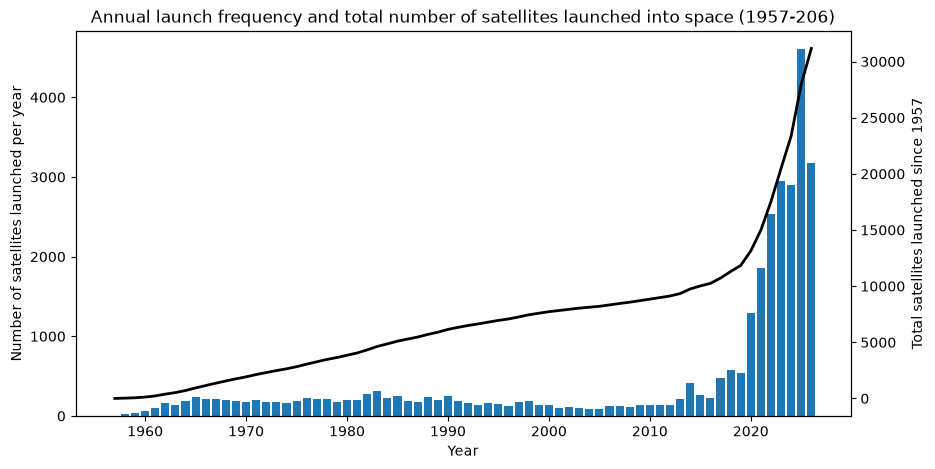

In [30]:
per_year = df.groupby("Year").size().reindex(range(df["Year"].min(), df["Year"].max() + 1), fill_value=0)
cumulative = per_year.cumsum()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.grid(False)
ax1.bar(per_year.index, per_year.values)
ax1.set_ylabel("Number of satellites launched per year")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(cumulative.index, cumulative.values, color="#000000", lw=2)
ax2.set_ylabel("Total satellites launched since 1957")

ax2.grid(False)
plt.title("Annual launch frequency and total number of satellites launched into space (1957-206)")
plt.show()

This distribution illustrates how the annual satellite launch frequency varies over time from 1957 to 2026. The center of the data is around 150 to 200 satellites per year. The spread of launch frequencies across most historical years sits between 50 and 500 satellites. The range of the data goes from 0 to approximately 4,600 satellites per year, giving a total range of around 4,600.

The shape of this distribution is unimodal with an extreme right skew. Most historical observations cluster at the lower end, while a long right tail stretches toward recent years.

## 5. Quel pays est le plus représenté dans l'espace ? (sous question 2)


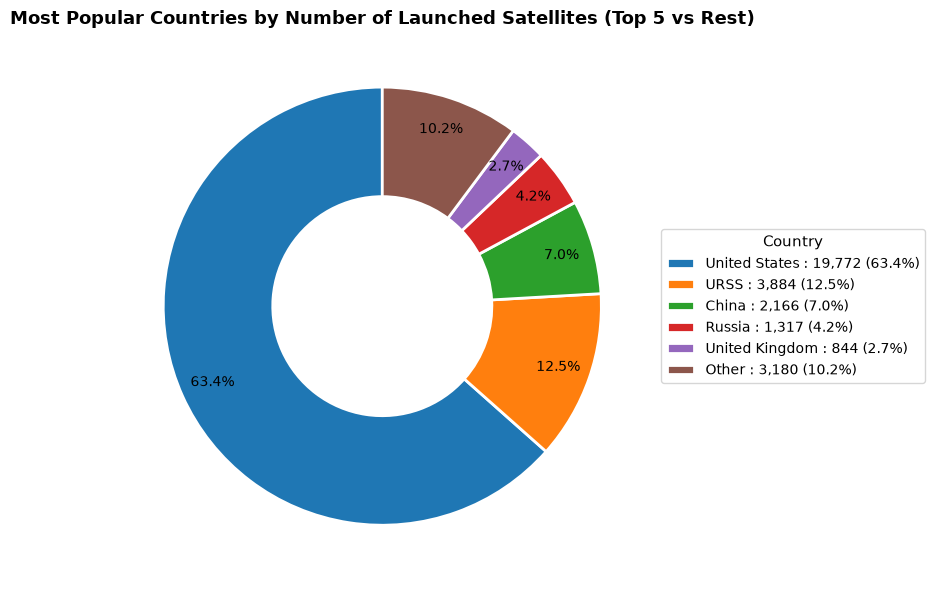

In [31]:
country_counts = df["SatState"].value_counts()

top_5 = country_counts.head(5)
others_sum = country_counts.iloc[5:].sum()

data_to_plot = pd.concat([top_5, pd.Series({"OTHER": others_sum})])

country_names = [
    readable_country(c) if c != "OTHER" else "Other"
    for c in data_to_plot.index
]

fig, ax = plt.subplots(figsize=(9, 6))

wedges, texts, autopcts = ax.pie(
    data_to_plot.values,
    autopct="%1.1f%%",
    pctdistance=0.85,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2)
)

total = data_to_plot.sum()
legend_labels = [
    f"{name} : {val:,} ({val/total*100:.1f}%)"
    for name, val in zip(country_names, data_to_plot.values)
]

ax.legend(
    wedges,
    legend_labels,
    title="Country",
    title_fontsize="11",
    loc="center",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)

ax.set_title(
    "Most Popular Countries by Number of Launched Satellites (Top 5 vs Rest)",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()



This donut chart illustrates how the total number of launched satellites is distributed across all the countries around the world. The major share of the data is concentrated in the United States, which accounts for 63.4% of all launched satellites. It also includes the other four major spacefaring nations, with the top 5 countries and the rest of the world.

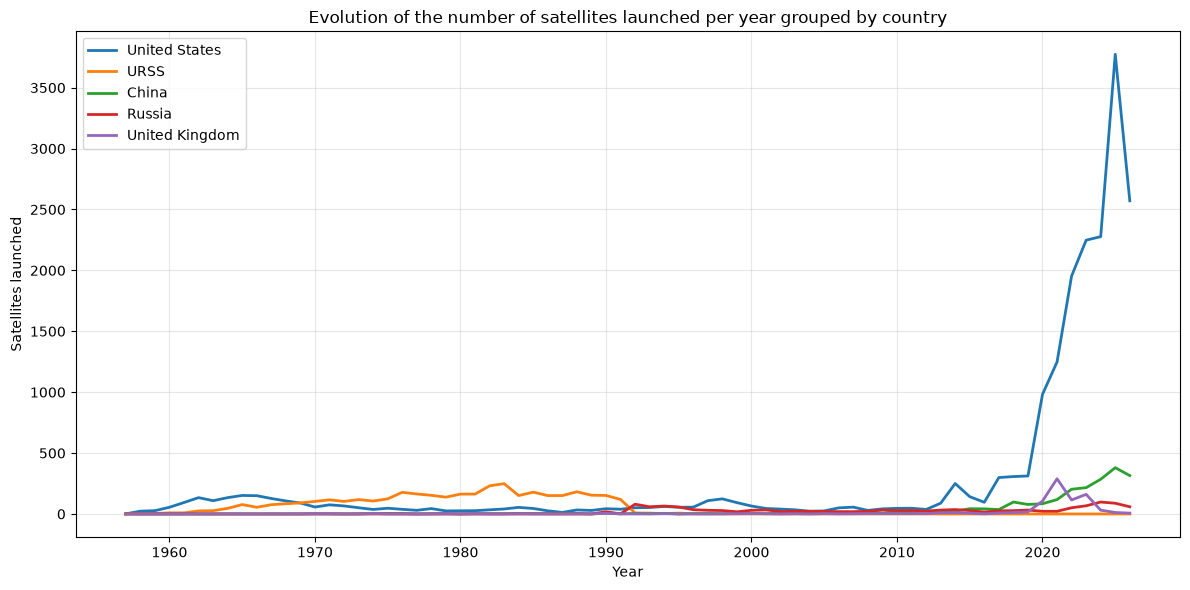

In [32]:
top5_codes = country_counts.head(5).index.tolist()

evo = (
    df[df["SatState"].isin(top5_codes)]
    .groupby(["Year", "SatState"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(df["Year"].min(), df["Year"].max() + 1), fill_value=0)
)

plt.figure(figsize=(12, 6))
for c in top5_codes:
    plt.plot(evo.index, evo[c], label=readable_country(c), linewidth=2)

plt.title("Evolution of the number of satellites launched per year grouped by country")
plt.xlabel("Year")
plt.ylabel("Satellites launched")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Quel est le lanceur (launch vehicle) le plus utilisé ? (sous question 3)

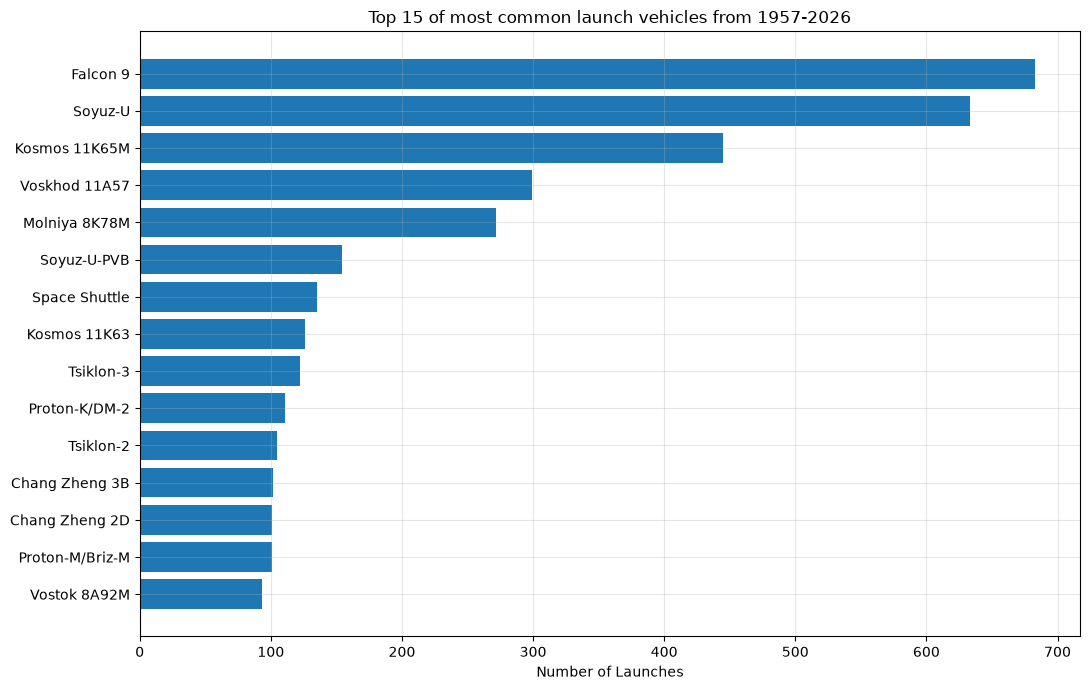

In [37]:
GroupByVehicules = df.drop_duplicates(subset=["Launch_Tag"])[["Launch_Tag", "Year", "LV_Type", "LVState"]]

# print(f"{len(GroupByVehicules):,} lancements distincts")

lv_counts = GroupByVehicules["LV_Type"].value_counts()
top_lv = lv_counts.head(15)

plt.figure(figsize=(11, 7))
plt.barh(top_lv.index[::-1], top_lv.values[::-1])
plt.title("Top 15 of most common launch vehicles from 1957-2026")
plt.xlabel("Number of Launches")
plt.tight_layout()
plt.show()